In [1]:
import requests
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://fantasy.premierleague.com/api/bootstrap-static/"
data = requests.get(url).json()

In [4]:
players_df = pd.DataFrame(data["elements"]) 
teams_df = pd.DataFrame(data["teams"]) # contains details about teams' performances home/away
positions_df = pd.DataFrame(data["element_types"]) # just how the team is supposed to be created.
events_df = pd.DataFrame(data["events"]) # contains details about GWs.

## The only important dataframe for us to look at are `players_df` and `teams_df`

In [5]:
pos_map = positions_df.set_index("id")["singular_name"].to_dict()
players_df["positions"] = players_df["element_type"].map(pos_map)

team_map = teams_df.set_index("id")["name"].to_dict()
players_df["team_name"] = players_df["team"].map(team_map)

players_df["price"] = players_df["now_cost"] / 10

clean = players_df[["first_name", "second_name", "team_name",
                    "price", "total_points", "element_type", "form", "minutes"]].sort_values("total_points", ascending=False)
clean = clean.rename(columns={'element_type': 'Position'})
position_mapping = {1: 'Goalkeeper', 2: 'Defender', 3: 'Midfielder', 4: 'Forward'}
clean['Position'] = clean['Position'].map(position_mapping)

# Best performing players

In [6]:
clean.head(20)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
511,Erling,Haaland,Man City,14.9,182,Forward,4.8,2098
538,Bruno,Borges Fernandes,Man Utd,9.8,141,Midfielder,8.8,1895
481,Antoine,Semenyo,Man City,7.9,139,Midfielder,4.8,2160
4,Gabriel,dos Santos Magalhães,Arsenal,7.1,135,Defender,5.8,1625
19,Declan,Rice,Arsenal,7.5,134,Midfielder,3.0,2055
582,Bruno,Guimarães Rodriguez Moura,Newcastle,7.0,131,Midfielder,3.5,1929
208,Igor Thiago,Nascimento Rodrigues,Brentford,7.0,131,Forward,2.8,2112
51,Morgan,Rogers,Aston Villa,7.6,123,Midfielder,5.5,2227
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,122,Forward,9.5,1797
266,Trevoh,Chalobah,Chelsea,5.8,121,Defender,4.8,2100


### Best performing Forwards

In [7]:
best_forward = clean[clean['Position'] == 'Forward']
best_forward.head(5)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
511,Erling,Haaland,Man City,14.9,182,Forward,4.8,2098
208,Igor Thiago,Nascimento Rodrigues,Brentford,7.0,131,Forward,2.8,2112
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,122,Forward,9.5,1797
758,Jarrod,Bowen,West Ham,7.7,115,Forward,6.2,2240
439,Dominic,Calvert-Lewin,Leeds,5.9,102,Forward,3.2,1663


### Best performing Midfielders

In [8]:
best_midfielder = clean[clean['Position'] == 'Midfielder']
best_midfielder.head(8)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
538,Bruno,Borges Fernandes,Man Utd,9.8,141,Midfielder,8.8,1895
481,Antoine,Semenyo,Man City,7.9,139,Midfielder,4.8,2160
19,Declan,Rice,Arsenal,7.5,134,Midfielder,3.0,2055
582,Bruno,Guimarães Rodriguez Moura,Newcastle,7.0,131,Midfielder,3.5,1929
51,Morgan,Rogers,Aston Villa,7.6,123,Midfielder,5.5,2227
391,Harry,Wilson,Fulham,6.1,118,Midfielder,4.0,1854
277,Enzo,Fernández,Chelsea,6.9,116,Midfielder,6.0,2054
358,James,Garner,Everton,5.2,109,Midfielder,3.5,2243


### Best performing Defenders

In [9]:
best_defender = clean[clean['Position'] == 'Defender']
best_defender.head(8)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
4,Gabriel,dos Santos Magalhães,Arsenal,7.1,135,Defender,5.8,1625
266,Trevoh,Chalobah,Chelsea,5.8,121,Defender,4.8,2100
7,Jurriën,Timber,Arsenal,6.4,121,Defender,4.2,1999
483,Marc,Guéhi,Man City,5.2,117,Defender,3.0,2070
346,James,Tarkowski,Everton,5.8,116,Defender,4.0,2250
300,Maxence,Lacroix,Crystal Palace,5.1,113,Defender,3.8,2250
681,Nordi,Mukiele,Sunderland,4.6,112,Defender,5.0,2062
491,Matheus,Nunes,Man City,5.4,111,Defender,4.2,1845


In [10]:
best_goalkeeper = clean[clean['Position'] == 'Goalkeeper']
best_goalkeeper.head(5)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
342,Jordan,Pickford,Everton,5.6,107,Goalkeeper,4.2,2250
0,David,Raya Martín,Arsenal,5.9,106,Goalkeeper,5.0,2250
678,Robin,Roefs,Sunderland,5.0,105,Goalkeeper,2.5,2250
175,Caoimhín,Kelleher,Brentford,4.6,94,Goalkeeper,3.2,2250
260,Robert,Lynch Sánchez,Chelsea,4.9,92,Goalkeeper,4.5,2074


# Points per million (PPM)

In [11]:
players_df["ppm"] = players_df["total_points"] / players_df["price"]
value_table = players_df[["first_name", "second_name", "team_name",
                    "price", "ppm", "total_points", "element_type", "form", "minutes"]].sort_values("ppm", ascending=False)
value_table = value_table.rename(columns={'element_type': 'Position'})
value_table['Position'] = value_table['Position'].map(position_mapping)
value_table.head(20)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
681,Nordi,Mukiele,Sunderland,4.6,24.347826,112,Defender,5.0,2062
483,Marc,Guéhi,Man City,5.2,22.500000,117,Defender,3.0,2070
300,Maxence,Lacroix,Crystal Palace,5.1,22.156863,113,Defender,3.8,2250
350,Michael,Keane,Everton,4.7,21.702128,102,Defender,1.5,1856
134,Marcos,Senesi Barón,Bournemouth,4.8,21.666667,104,Defender,4.0,2118
700,Micky,van de Ven,Spurs,4.5,21.555556,97,Defender,2.0,2059
303,Chris,Richards,Crystal Palace,4.4,21.136364,93,Defender,4.5,1882
678,Robin,Roefs,Sunderland,5.0,21.000000,105,Goalkeeper,2.5,2250
680,Omar,Alderete,Sunderland,4.1,20.975610,86,Defender,2.2,1824
358,James,Garner,Everton,5.2,20.961538,109,Midfielder,3.5,2243


### PPM for forwards

In [12]:
ppm_forwards = value_table[value_table["Position"] == 'Forward']
ppm_forwards.head(5)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
208,Igor Thiago,Nascimento Rodrigues,Brentford,7.0,18.714286,131,Forward,2.8,2112
439,Dominic,Calvert-Lewin,Leeds,5.9,17.288136,102,Forward,3.2,1663
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,16.052632,122,Forward,9.5,1797
758,Jarrod,Bowen,West Ham,7.7,14.935065,115,Forward,6.2,2240
160,Junior,Kroupi,Bournemouth,4.7,14.042553,66,Forward,3.0,836


### PPM for midfielders

In [13]:
ppm_midfielders = value_table[value_table["Position"] == 'Midfielder']
ppm_midfielders.head(8)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
358,James,Garner,Everton,5.2,20.961538,109,Midfielder,3.5,2243
619,Elliot,Anderson,Nott'm Forest,5.3,20.377358,108,Midfielder,5.2,2250
437,Anton,Stach,Leeds,4.8,20.208333,97,Midfielder,2.5,1693
24,Martín,Zubimendi Ibáñez,Arsenal,5.2,19.423077,101,Midfielder,6.0,2085
391,Harry,Wilson,Fulham,6.1,19.344262,118,Midfielder,4.0,1854
544,Carlos Henrique,Casimiro,Man Utd,5.6,19.285714,108,Midfielder,5.2,1634
467,Ryan,Gravenberch,Liverpool,5.6,18.928571,106,Midfielder,3.0,2028
582,Bruno,Guimarães Rodriguez Moura,Newcastle,7.0,18.714286,131,Midfielder,3.5,1929


### PPM for defenders

In [14]:
ppm_defenders = value_table[value_table["Position"] == 'Defender']
ppm_defenders.head(8)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
681,Nordi,Mukiele,Sunderland,4.6,24.347826,112,Defender,5.0,2062
483,Marc,Guéhi,Man City,5.2,22.500000,117,Defender,3.0,2070
300,Maxence,Lacroix,Crystal Palace,5.1,22.156863,113,Defender,3.8,2250
350,Michael,Keane,Everton,4.7,21.702128,102,Defender,1.5,1856
134,Marcos,Senesi Barón,Bournemouth,4.8,21.666667,104,Defender,4.0,2118
700,Micky,van de Ven,Spurs,4.5,21.555556,97,Defender,2.0,2059
303,Chris,Richards,Crystal Palace,4.4,21.136364,93,Defender,4.5,1882
680,Omar,Alderete,Sunderland,4.1,20.975610,86,Defender,2.2,1824


### PPM for goalkeepers

In [15]:
ppm_goalkeepers = value_table[value_table["Position"] == 'Goalkeeper']
ppm_goalkeepers.head(5)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
678,Robin,Roefs,Sunderland,5.0,21.000000,105,Goalkeeper,2.5,2250
175,Caoimhín,Kelleher,Brentford,4.6,20.434783,94,Goalkeeper,3.2,2250
342,Jordan,Pickford,Everton,5.6,19.107143,107,Goalkeeper,4.2,2250
260,Robert,Lynch Sánchez,Chelsea,4.9,18.775510,92,Goalkeeper,4.5,2074
121,Martin,Dúbravka,Burnley,4.0,18.750000,75,Goalkeeper,3.0,2250


# Most in form players

In [16]:
in_form = value_table.sort_values("form", ascending=False)
in_form.head(25)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,16.052632,122,Forward,9.5,1797
749,Crysencio,Summerville,West Ham,5.6,13.214286,74,Midfielder,9.0,1497
538,Bruno,Borges Fernandes,Man Utd,9.8,14.387755,141,Midfielder,8.8,1895
275,Cole,Palmer,Chelsea,10.5,6.380952,67,Midfielder,7.8,903
519,Bryan,Mbeumo,Man Utd,8.6,11.976744,103,Midfielder,7.2,1719
764,Mateus Gonçalo,Espanha Fernandes,West Ham,5.5,16.727273,92,Midfielder,7.2,1853
465,Dominik,Szoboszlai,Liverpool,6.7,14.477612,97,Midfielder,6.5,2152
460,Florian,Wirtz,Liverpool,8.4,11.547619,97,Midfielder,6.5,1760
172,Rayan Vitor,Simplício Rocha,Bournemouth,5.5,2.363636,13,Midfielder,6.5,108
441,James,Justin,Leeds,3.9,11.025641,43,Defender,6.2,744


## In-form forwards only

In [17]:
inform_forwards = in_form[in_form['Position'] == 'Forward']
inform_forwards.head(5)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,16.052632,122,Forward,9.5,1797
758,Jarrod,Bowen,West Ham,7.7,14.935065,115,Forward,6.2,2240
365,Thierno,Barry,Everton,5.7,11.052632,63,Forward,5.2,1425
31,Viktor,Gyökeres,Arsenal,8.7,8.620690,75,Forward,5.2,1482
511,Erling,Haaland,Man City,14.9,12.214765,182,Forward,4.8,2098


## In-form defenders only

In [18]:
inform_defenders = in_form[in_form['Position'] == 'Defender']
inform_defenders.head(8)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
441,James,Justin,Leeds,3.9,11.025641,43,Defender,6.2,744
773,Axel,Disasi,West Ham,4.5,1.333333,6,Defender,6.0,90
4,Gabriel,dos Santos Magalhães,Arsenal,7.1,19.014085,135,Defender,5.8,1625
530,Patrick,Dorgu,Man Utd,4.3,17.209302,74,Defender,5.8,1329
139,James,Hill,Bournemouth,3.9,12.820513,50,Defender,5.5,932
5,William,Saliba,Arsenal,6.1,13.606557,83,Defender,5.5,1714
348,Jake,O'Brien,Everton,4.9,17.959184,88,Defender,5.2,2118
745,Aaron,Wan-Bissaka,West Ham,4.1,11.219512,46,Defender,5.2,1371


## In-form midfielders only

In [65]:
inform_midfielders = in_form[in_form['Position'] == 'Midfielder']
inform_midfielders.head(8)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
749,Crysencio,Summerville,West Ham,5.6,13.214286,74,Midfielder,9.0,1497
538,Bruno,Borges Fernandes,Man Utd,9.8,14.387755,141,Midfielder,8.8,1895
275,Cole,Palmer,Chelsea,10.5,6.380952,67,Midfielder,7.8,903
519,Bryan,Mbeumo,Man Utd,8.6,11.976744,103,Midfielder,7.2,1719
764,Mateus Gonçalo,Espanha Fernandes,West Ham,5.5,16.727273,92,Midfielder,7.2,1853
465,Dominik,Szoboszlai,Liverpool,6.7,14.477612,97,Midfielder,6.5,2152
460,Florian,Wirtz,Liverpool,8.4,11.547619,97,Midfielder,6.5,1760
172,Rayan Vitor,Simplício Rocha,Bournemouth,5.5,2.363636,13,Midfielder,6.5,108


In [66]:
inform_midfielders_arsenal = in_form[(in_form['Position'] == 'Midfielder') & (in_form['team_name'] == 'Arsenal')]
inform_midfielders_arsenal.head()

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
24,Martín,Zubimendi Ibáñez,Arsenal,5.2,19.423077,101,Midfielder,6.0,2085
16,Noni,Madueke,Arsenal,6.8,5.441176,37,Midfielder,4.2,695
18,Leandro,Trossard,Arsenal,6.8,13.529412,92,Midfielder,3.0,1415
19,Declan,Rice,Arsenal,7.5,17.866667,134,Midfielder,3.0,2055
17,Gabriel,Martinelli Silva,Arsenal,6.8,5.441176,37,Midfielder,2.2,604


## In-form goalkeepers only

In [20]:
inform_keeper = in_form[in_form['Position'] == 'Goalkeeper'].sort_values("form", ascending=False)
inform_keeper.head(5)

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
36,Emiliano,Martínez Romero,Aston Villa,5.0,16.800000,84,Goalkeeper,5.0,1845
0,David,Raya Martín,Arsenal,5.9,17.966102,106,Goalkeeper,5.0,2250
260,Robert,Lynch Sánchez,Chelsea,4.9,18.775510,92,Goalkeeper,4.5,2074
342,Jordan,Pickford,Everton,5.6,19.107143,107,Goalkeeper,4.2,2250
604,Matz,Sels,Nott'm Forest,4.6,13.260870,61,Goalkeeper,4.2,1677


### Plot of price vs total points

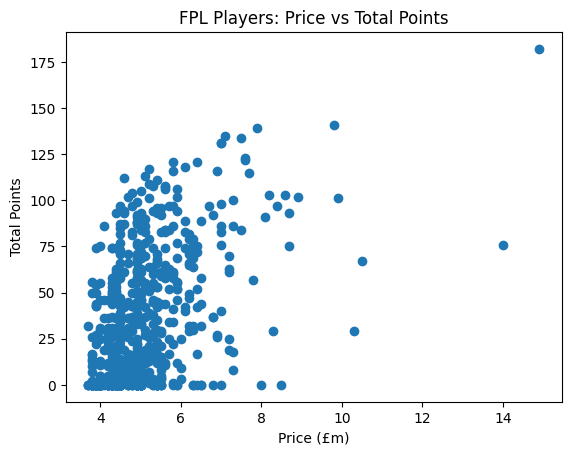

In [21]:
import matplotlib.pyplot as plt

plt.scatter(players_df["price"], players_df["total_points"])
plt.xlabel("Price (£m)")
plt.ylabel("Total Points")
plt.title("FPL Players: Price vs Total Points")
plt.show()

### November 20, 2025
## Working with teams

In [22]:
teams_df.head(10)

,code,draw,form,id,loss,name,played,points,position,short_name,...,team_division,unavailable,win,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,3,0,None,1,0,Arsenal,0,0,1,ARS,...,None,False,0,1300,1375,1340,1400,1260,1350,1
1,7,0,None,2,0,Aston Villa,0,0,3,AVL,...,None,False,0,1145,1185,1150,1170,1140,1200,2
2,90,0,None,3,0,Burnley,0,0,19,BUR,...,None,False,0,1055,1095,1010,1090,1100,1100,43
3,91,0,None,4,0,Bournemouth,0,0,11,BOU,...,None,False,0,1150,1220,1100,1240,1200,1200,127
4,94,0,None,5,0,Brentford,0,0,7,BRE,...,None,False,0,1135,1175,1100,1110,1170,1240,130
5,36,0,None,6,0,Brighton,0,0,14,BHA,...,None,False,0,1150,1160,1090,1110,1210,1210,131
6,8,0,None,7,0,Chelsea,0,0,5,CHE,...,None,False,0,1180,1190,1140,1160,1220,1220,4
7,31,0,None,8,0,Crystal Palace,0,0,13,CRY,...,None,False,0,1165,1205,1150,1150,1180,1260,6
8,11,0,None,9,0,Everton,0,0,8,EVE,...,None,False,0,1100,1130,1110,1130,1090,1130,7
9,54,0,None,10,0,Fulham,0,0,10,FUL,...,None,False,0,1090,1130,1080,1140,1100,1120,34


### Strongest home team

In [23]:
strongest_home_team = teams_df[["name", "position", "strength_overall_home", "strength_attack_home", "strength_defence_home"]].sort_values("strength_overall_home", ascending=False)
strongest_home_team.head(10)

,name,position,strength_overall_home,strength_attack_home,strength_defence_home
0,Arsenal,1,1300,1340,1260
12,Man City,2,1250,1210,1290
11,Liverpool,6,1230,1170,1290
6,Chelsea,5,1180,1140,1220
17,Spurs,15,1165,1130,1200
7,Crystal Palace,13,1165,1150,1180
14,Newcastle,12,1160,1170,1150
3,Bournemouth,11,1150,1100,1200
5,Brighton,14,1150,1090,1210
1,Aston Villa,3,1145,1150,1140


### Strongest away team

In [24]:
strongest_away_team = teams_df[["name", "position", "strength_overall_away", "strength_attack_away", "strength_defence_away"]].sort_values("strength_overall_away", ascending=False)
strongest_away_team.head(10)

,name,position,strength_overall_away,strength_attack_away,strength_defence_away
0,Arsenal,1,1375,1400,1350
12,Man City,2,1305,1230,1380
11,Liverpool,6,1265,1210,1320
3,Bournemouth,11,1220,1240,1200
14,Newcastle,12,1220,1180,1260
7,Crystal Palace,13,1205,1150,1260
13,Man Utd,4,1205,1150,1260
6,Chelsea,5,1190,1160,1220
1,Aston Villa,3,1185,1170,1200
17,Spurs,15,1175,1150,1200


### Strongest team

In [25]:
strongest = teams_df[["name", "strength", "position"]].sort_values(by=["strength", "position"], ascending=[False, True])
strongest.head(20)

,name,strength,position
0,Arsenal,5,1
12,Man City,4,2
11,Liverpool,4,6
1,Aston Villa,3,3
13,Man Utd,3,4
6,Chelsea,3,5
4,Brentford,3,7
8,Everton,3,8
16,Sunderland,3,9
9,Fulham,3,10


## Explore the 'element_types' class

In [26]:
positions_df.head(5)

,id,plural_name,plural_name_short,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
0,1,Goalkeepers,GKP,Goalkeeper,GKP,2,None,None,1,1,True,[12],94
1,2,Defenders,DEF,Defender,DEF,5,None,None,3,5,False,[],265
2,3,Midfielders,MID,Midfielder,MID,5,None,None,2,5,False,[],367
3,4,Forwards,FWD,Forward,FWD,3,None,None,1,3,False,[],91


## Explore the 'events' class


In [27]:
events_df.head(5)

,id,name,deadline_time,release_time,average_entry_score,finished,data_checked,highest_scoring_entry,deadline_time_epoch,deadline_time_game_offset,...,ranked_count,overrides,chip_plays,most_selected,most_transferred_in,top_element,top_element_info,transfers_made,most_captained,most_vice_captained
0,1,Gameweek 1,2025-08-15T17:30:00Z,None,54,True,True,3772644.0,1755279000,0,...,9469118,"{'rules': {}, 'scoring': {}, 'element_types': ...","[{'chip_name': 'bboost', 'num_played': 342779}...",235.0,1.0,531.0,"{'id': 531, 'points': 17}",0,381.0,235.0
1,2,Gameweek 2,2025-08-22T17:30:00Z,None,51,True,True,2963810.0,1755883800,0,...,10752422,"{'rules': {}, 'scoring': {}, 'element_types': ...","[{'chip_name': 'bboost', 'num_played': 206501}...",235.0,427.0,8.0,"{'id': 8, 'points': 24}",18178809,381.0,235.0
2,3,Gameweek 3,2025-08-30T10:00:00Z,None,48,True,True,4374360.0,1756548000,0,...,11304791,"{'rules': {}, 'scoring': {}, 'element_types': ...","[{'chip_name': 'bboost', 'num_played': 181694}...",249.0,82.0,260.0,"{'id': 260, 'points': 15}",27802596,430.0,381.0
3,4,Gameweek 4,2025-09-13T10:00:00Z,None,63,True,True,7997042.0,1757757600,0,...,11641518,"{'rules': {}, 'scoring': {}, 'element_types': ...","[{'chip_name': 'bboost', 'num_played': 151177}...",249.0,419.0,26.0,"{'id': 26, 'points': 16}",27408255,381.0,249.0
4,5,Gameweek 5,2025-09-20T10:00:00Z,None,42,True,True,9985225.0,1758362400,0,...,11803614,"{'rules': {}, 'scoring': {}, 'element_types': ...","[{'chip_name': 'bboost', 'num_played': 231274}...",249.0,82.0,660.0,"{'id': 660, 'points': 15}",16533109,381.0,249.0


### Find the highest average_entry_score in the entire gameweek timeline for this season

In [28]:
highest_average_score = events_df["average_entry_score"].max()
# highest_average_gw = events_df["name", "average_entry_score"]
highest_average_gw = events_df.loc[events_df["average_entry_score"] == highest_average_score, ["name", "average_entry_score"]]
highest_average_gw

,name,average_entry_score
16,Gameweek 17,66


In [29]:
# 1. Get the index of the row with the maximum score
max_score_index = events_df['average_entry_score'].idxmax()

# 2. Use that index to select the corresponding row
event_with_highest_score = events_df.loc[max_score_index]

# You can then extract the name and score:
highest_score_name = event_with_highest_score['name']
print(highest_score_name)
highest_average_entry_score = event_with_highest_score['average_entry_score']
print(highest_average_entry_score)

Gameweek 17
66


## For transferring of players from my team with the least form.

In [30]:
# first create a dataframe where the names of the players are combined

combined = clean.copy(deep=True)
combined['combined_name'] = clean['first_name'] +  ' ' + clean['second_name']
combined.drop(columns=['first_name', 'second_name'], inplace=True)
combined.head()

,team_name,price,total_points,Position,form,minutes,combined_name
511,Man City,14.9,182,Forward,4.8,2098,Erling Haaland
538,Man Utd,9.8,141,Midfielder,8.8,1895,Bruno Borges Fernandes
481,Man City,7.9,139,Midfielder,4.8,2160,Antoine Semenyo
4,Arsenal,7.1,135,Defender,5.8,1625,Gabriel dos Santos Magalhães
19,Arsenal,7.5,134,Midfielder,3.0,2055,Declan Rice


In [58]:
# now we'll select the players that we've selected in our team

player_names = ['Erling Haaland', 'Ollie Watkins', 'Dominic Calvert-Lewin',
                'Cole Palmer', 'Declan Rice', 'Enzo Fernández', 'Harry Wilson', 'Bruno Guimarães Rodriguez Moura',
                'Nordi Mukiele', 'Micky van de Ven', 'Michael Keane', 'Trevoh Chalobah', "Gabriel dos Santos Magalhães",
                'Jordan Pickford', 'Caoimhín Kelleher']

my_team_form_evaluation = combined[combined['combined_name'].isin(player_names)].sort_values('form', ascending=False)
my_team_form_evaluation

,team_name,price,total_points,Position,form,minutes,combined_name
275,Chelsea,10.5,67,Midfielder,7.8,903,Cole Palmer
277,Chelsea,6.9,116,Midfielder,6.0,2054,Enzo Fernández
4,Arsenal,7.1,135,Defender,5.8,1625,Gabriel dos Santos Magalhães
681,Sunderland,4.6,112,Defender,5.0,2062,Nordi Mukiele
511,Man City,14.9,182,Forward,4.8,2098,Erling Haaland
266,Chelsea,5.8,121,Defender,4.8,2100,Trevoh Chalobah
342,Everton,5.6,107,Goalkeeper,4.2,2250,Jordan Pickford
391,Fulham,6.1,118,Midfielder,4.0,1854,Harry Wilson
582,Newcastle,7.0,131,Midfielder,3.5,1929,Bruno Guimarães Rodriguez Moura
175,Brentford,4.6,94,Goalkeeper,3.2,2250,Caoimhín Kelleher


In [32]:
# There are a few set of options in whom to pick
inform_midfielders.head()

,first_name,second_name,team_name,price,ppm,total_points,Position,form,minutes
749,Crysencio,Summerville,West Ham,5.6,13.214286,74,Midfielder,9.0,1497
538,Bruno,Borges Fernandes,Man Utd,9.8,14.387755,141,Midfielder,8.8,1895
275,Cole,Palmer,Chelsea,10.5,6.380952,67,Midfielder,7.8,903
519,Bryan,Mbeumo,Man Utd,8.6,11.976744,103,Midfielder,7.2,1719
764,Mateus Gonçalo,Espanha Fernandes,West Ham,5.5,16.727273,92,Midfielder,7.2,1853


### I think that it's time to decide the best players to pick from. Choose the best players for the team.

As per the suggestions:
1. players @ home vs. players @ away
2. formation isn't really a factor, choose the best based on your players

In [33]:
combined['form'] = combined['form'].astype(float) #this was really an eye opening moment.

In [59]:
# this week's team

# now we'll select the players that we've selected in our team

player_names = ['Erling Haaland', 'Dominic Calvert-Lewin', 'Ollie Watkins',
                'Enzo Fernández', 'Declan Rice', 'Bruno Guimarães Rodriguez Moura', 'Harry Wilson', 'Cole Palmer',
                'Gabriel dos Santos Magalhães', 'Micky van de Ven', 'Diogo Dalot Teixeira', 'Trevoh Chalobah', "Nordi Mukiele",
                'Jordan Pickford', 'Caoimhín Kelleher']

my_team_form_evaluation = combined[combined['combined_name'].isin(player_names)].sort_values('form', ascending=False)
my_team_form_evaluation

,team_name,price,total_points,Position,form,minutes,combined_name
275,Chelsea,10.5,67,Midfielder,7.8,903,Cole Palmer
277,Chelsea,6.9,116,Midfielder,6.0,2054,Enzo Fernández
4,Arsenal,7.1,135,Defender,5.8,1625,Gabriel dos Santos Magalhães
681,Sunderland,4.6,112,Defender,5.0,2062,Nordi Mukiele
529,Man Utd,4.5,85,Defender,5.0,1759,Diogo Dalot Teixeira
266,Chelsea,5.8,121,Defender,4.8,2100,Trevoh Chalobah
511,Man City,14.9,182,Forward,4.8,2098,Erling Haaland
342,Everton,5.6,107,Goalkeeper,4.2,2250,Jordan Pickford
391,Fulham,6.1,118,Midfielder,4.0,1854,Harry Wilson
582,Newcastle,7.0,131,Midfielder,3.5,1929,Bruno Guimarães Rodriguez Moura


In [35]:
my_team_form_evaluation.sort_values('form', ascending=False)

,team_name,price,total_points,Position,form,minutes,combined_name
275,Chelsea,10.5,67,Midfielder,7.8,903,Cole Palmer
4,Arsenal,7.1,135,Defender,5.8,1625,Gabriel dos Santos Magalhães
681,Sunderland,4.6,112,Defender,5.0,2062,Nordi Mukiele
529,Man Utd,4.5,85,Defender,5.0,1759,Diogo Dalot Teixeira
511,Man City,14.9,182,Forward,4.8,2098,Erling Haaland
266,Chelsea,5.8,121,Defender,4.8,2100,Trevoh Chalobah
342,Everton,5.6,107,Goalkeeper,4.2,2250,Jordan Pickford
391,Fulham,6.1,118,Midfielder,4.0,1854,Harry Wilson
582,Newcastle,7.0,131,Midfielder,3.5,1929,Bruno Guimarães Rodriguez Moura
501,Man City,6.5,89,Midfielder,3.2,1048,Rayan Cherki


### just random exploration into data

In [36]:
teams_df.columns

Index(['code', 'draw', 'form', 'id', 'loss', 'name', 'played', 'points',
       'position', 'short_name', 'strength', 'team_division', 'unavailable',
       'win', 'strength_overall_home', 'strength_overall_away',
       'strength_attack_home', 'strength_attack_away', 'strength_defence_home',
       'strength_defence_away', 'pulse_id'],
      dtype='object')

In [37]:
teams_df.drop(['form', 'id', 'loss', 'played', 'win', 'code', 'draw',
               'points', 'team_division', 'unavailable'], axis=1, inplace=True)

# Home overall

In [38]:
strong_home_attack = teams_df.sort_values('strength_attack_home', ascending=False)
strong_home_attack.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23
1,Aston Villa,3,AVL,3,1145,1185,1150,1170,1140,1200,2


In [39]:
strong_home_defense = teams_df.sort_values('strength_defence_home', ascending=False)
strong_home_defense.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
6,Chelsea,5,CHE,3,1180,1190,1140,1160,1220,1220,4
5,Brighton,14,BHA,3,1150,1160,1090,1110,1210,1210,131


In [40]:
strong_overall = teams_df.sort_values('strength_overall_home', ascending=False)
strong_overall.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
6,Chelsea,5,CHE,3,1180,1190,1140,1160,1220,1220,4
17,Spurs,15,TOT,3,1165,1175,1130,1150,1200,1200,21


# Away overall

In [41]:
strong_away_attack = teams_df.sort_values('strength_attack_away', ascending=False)
strong_away_attack.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
3,Bournemouth,11,BOU,3,1150,1220,1100,1240,1200,1200,127
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23


In [42]:
strong_away_defense = teams_df.sort_values('strength_defence_away', ascending=False)
strong_away_defense.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
13,Man Utd,4,MUN,3,1135,1205,1100,1150,1170,1260,12
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23


In [43]:
strong_overall_away = teams_df.sort_values('strength_overall_away', ascending=False)
strong_overall_away.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
3,Bournemouth,11,BOU,3,1150,1220,1100,1240,1200,1200,127
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23


## Strongest attacking side

In [44]:
strong_home_attack.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23
1,Aston Villa,3,AVL,3,1145,1185,1150,1170,1140,1200,2


In [45]:
strong_away_attack.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
3,Bournemouth,11,BOU,3,1150,1220,1100,1240,1200,1200,127
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23


# Attacking players preference: `Arsenal`, `Man City`, `Liverpool`, `Newcastle` (for both home and away)

In [46]:
strong_home_defense.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
6,Chelsea,5,CHE,3,1180,1190,1140,1160,1220,1220,4
5,Brighton,14,BHA,3,1150,1160,1090,1110,1210,1210,131


In [47]:
strong_away_defense.head()

,name,position,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
12,Man City,2,MCI,4,1250,1305,1210,1230,1290,1380,11
0,Arsenal,1,ARS,5,1300,1375,1340,1400,1260,1350,1
11,Liverpool,6,LIV,4,1230,1265,1170,1210,1290,1320,10
13,Man Utd,4,MUN,3,1135,1205,1100,1150,1170,1260,12
14,Newcastle,12,NEW,3,1160,1220,1170,1180,1150,1260,23


# Defensive player prefernces: `Man City`, `Liverpool`, `Arsenal`

### Best players from Arsenal

In [48]:
dream_arsenal = clean[clean['team_name'] == 'Arsenal']
dream_arsenal.head(10)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
4,Gabriel,dos Santos Magalhães,Arsenal,7.1,135,Defender,5.8,1625
19,Declan,Rice,Arsenal,7.5,134,Midfielder,3.0,2055
7,Jurriën,Timber,Arsenal,6.4,121,Defender,4.2,1999
0,David,Raya Martín,Arsenal,5.9,106,Goalkeeper,5.0,2250
14,Bukayo,Saka,Arsenal,9.9,101,Midfielder,0.8,1543
24,Martín,Zubimendi Ibáñez,Arsenal,5.2,101,Midfielder,6.0,2085
18,Leandro,Trossard,Arsenal,6.8,92,Midfielder,3.0,1415
6,Riccardo,Calafiori,Arsenal,5.6,84,Defender,1.8,1337
5,William,Saliba,Arsenal,6.1,83,Defender,5.5,1714
31,Viktor,Gyökeres,Arsenal,8.7,75,Forward,5.2,1482


In [49]:
# most in-form Arsenal Player

sorted_dream = dream_arsenal.sort_values('form', ascending=False)
sorted_dream.head()

,first_name,second_name,team_name,price,total_points,Position,form,minutes
24,Martín,Zubimendi Ibáñez,Arsenal,5.2,101,Midfielder,6.0,2085
4,Gabriel,dos Santos Magalhães,Arsenal,7.1,135,Defender,5.8,1625
5,William,Saliba,Arsenal,6.1,83,Defender,5.5,1714
31,Viktor,Gyökeres,Arsenal,8.7,75,Forward,5.2,1482
0,David,Raya Martín,Arsenal,5.9,106,Goalkeeper,5.0,2250


### Man City

In [50]:
dream_city = clean[clean['team_name'] == 'Man City']
dream_city.head(10)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
511,Erling,Haaland,Man City,14.9,182,Forward,4.8,2098
481,Antoine,Semenyo,Man City,7.9,139,Midfielder,4.8,2160
483,Marc,Guéhi,Man City,5.2,117,Defender,3.0,2070
491,Matheus,Nunes,Man City,5.4,111,Defender,4.2,1845
498,Phil,Foden,Man City,8.2,103,Midfielder,0.8,1643
492,Rúben,dos Santos Gato Alves Dias,Man City,5.5,96,Defender,0.2,1734
501,Rayan,Cherki,Man City,6.5,89,Midfielder,3.2,1048
495,Nico,O'Reilly,Man City,4.9,87,Defender,2.0,1791
512,Gianluigi,Donnarumma,Man City,5.6,84,Goalkeeper,3.8,1980
508,Tijjani,Reijnders,Man City,5.1,83,Midfielder,1.2,1423


In [51]:
# in-form man city players

form_city = dream_city.sort_values('form', ascending=False)
form_city.head()

,first_name,second_name,team_name,price,total_points,Position,form,minutes
500,Bernardo,Mota Veiga de Carvalho e Silva,Man City,6.2,66,Midfielder,5.0,1839
511,Erling,Haaland,Man City,14.9,182,Forward,4.8,2098
481,Antoine,Semenyo,Man City,7.9,139,Midfielder,4.8,2160
491,Matheus,Nunes,Man City,5.4,111,Defender,4.2,1845
512,Gianluigi,Donnarumma,Man City,5.6,84,Goalkeeper,3.8,1980


### Liverpool

In [52]:
dream_liverpool = clean[clean['team_name'] == 'Liverpool']
dream_liverpool.head(10)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
467,Ryan,Gravenberch,Liverpool,5.6,106,Midfielder,3.0,2028
476,Hugo,Ekitiké,Liverpool,8.9,102,Forward,4.5,1422
465,Dominik,Szoboszlai,Liverpool,6.7,97,Midfielder,6.5,2152
460,Florian,Wirtz,Liverpool,8.4,97,Midfielder,6.5,1760
451,Virgil,van Dijk,Liverpool,5.9,94,Defender,3.8,2250
452,Ibrahima,Konaté,Liverpool,5.4,93,Defender,3.5,2056
462,Cody,Gakpo,Liverpool,7.3,86,Midfielder,2.5,1668
459,Mohamed,Salah,Liverpool,14.0,76,Midfielder,3.0,1446
444,Alisson,Becker,Liverpool,5.4,68,Goalkeeper,1.5,1800
449,Milos,Kerkez,Liverpool,5.6,59,Defender,1.8,1715


In [53]:
# in-form liverpool players

form_liverpool = dream_liverpool.sort_values('form', ascending=False)
form_liverpool.head()

,first_name,second_name,team_name,price,total_points,Position,form,minutes
465,Dominik,Szoboszlai,Liverpool,6.7,97,Midfielder,6.5,2152
460,Florian,Wirtz,Liverpool,8.4,97,Midfielder,6.5,1760
476,Hugo,Ekitiké,Liverpool,8.9,102,Forward,4.5,1422
451,Virgil,van Dijk,Liverpool,5.9,94,Defender,3.8,2250
452,Ibrahima,Konaté,Liverpool,5.4,93,Defender,3.5,2056


### Chelsea

In [54]:
dream_chelsea = clean[clean['team_name'] == 'Chelsea']
dream_chelsea.head(10)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,122,Forward,9.5,1797
266,Trevoh,Chalobah,Chelsea,5.8,121,Defender,4.8,2100
277,Enzo,Fernández,Chelsea,6.9,116,Midfielder,6.0,2054
276,Pedro,Lomba Neto,Chelsea,7.0,98,Midfielder,2.5,1956
265,Reece,James,Chelsea,5.7,97,Defender,3.5,1534
260,Robert,Lynch Sánchez,Chelsea,4.9,92,Goalkeeper,4.5,2074
264,Marc,Cucurella Saseta,Chelsea,6.1,89,Defender,5.0,1840
281,Moisés,Caicedo Corozo,Chelsea,5.7,84,Midfielder,3.8,1684
268,Malo,Gusto,Chelsea,4.9,77,Defender,1.0,1386
275,Cole,Palmer,Chelsea,10.5,67,Midfielder,7.8,903


In [55]:
# in-form chelsea players

form_chelsea = dream_chelsea.sort_values('form', ascending=False)
form_chelsea.head()

,first_name,second_name,team_name,price,total_points,Position,form,minutes
287,João Pedro,Junqueira de Jesus,Chelsea,7.6,122,Forward,9.5,1797
275,Cole,Palmer,Chelsea,10.5,67,Midfielder,7.8,903
277,Enzo,Fernández,Chelsea,6.9,116,Midfielder,6.0,2054
264,Marc,Cucurella Saseta,Chelsea,6.1,89,Defender,5.0,1840
266,Trevoh,Chalobah,Chelsea,5.8,121,Defender,4.8,2100


### Aston Villa

In [56]:
dream_villa = clean[clean['team_name'] == 'Aston Villa']
dream_villa.head(10)

,first_name,second_name,team_name,price,total_points,Position,form,minutes
51,Morgan,Rogers,Aston Villa,7.6,123,Midfielder,5.5,2227
40,Matty,Cash,Aston Villa,4.9,99,Defender,3.0,2131
67,Ollie,Watkins,Aston Villa,8.7,93,Forward,3.0,1826
36,Emiliano,Martínez Romero,Aston Villa,5.0,84,Goalkeeper,5.0,1845
42,Ezri,Konsa Ngoyo,Aston Villa,4.4,74,Defender,3.0,2135
54,Emiliano,Buendía Stati,Aston Villa,5.3,74,Midfielder,4.0,1091
41,Lucas,Digne,Aston Villa,4.5,72,Defender,2.0,1309
57,John,McGinn,Aston Villa,5.4,71,Midfielder,0.2,1591
61,Boubacar,Kamara,Aston Villa,4.9,61,Midfielder,0.0,1410
56,Donyell,Malen,Aston Villa,5.1,55,Midfielder,0.0,640


In [57]:
# in-form aston villa players

form_villa = dream_villa.sort_values('form', ascending=False)
form_villa.head()

,first_name,second_name,team_name,price,total_points,Position,form,minutes
51,Morgan,Rogers,Aston Villa,7.6,123,Midfielder,5.5,2227
36,Emiliano,Martínez Romero,Aston Villa,5.0,84,Goalkeeper,5.0,1845
54,Emiliano,Buendía Stati,Aston Villa,5.3,74,Midfielder,4.0,1091
67,Ollie,Watkins,Aston Villa,8.7,93,Forward,3.0,1826
42,Ezri,Konsa Ngoyo,Aston Villa,4.4,74,Defender,3.0,2135


# Transfer strategy (as of january 28th, 2026)

1. Add more players from Chelsea: (Enzo/Joao Pedro/Estevao)
2. Remove: (Haaland/Cherki/Palmer/Dalot/Guiamaraes)
3. Other addition options: (Igor Thiago/Malick Thiaw/Morgan Rogers)

So, the previous team almost remains intact, just one player was brought in Enzo..